In [4]:
from google.colab import files
uploaded = files.upload()  # upload email_ab_test_data.csv again

Saving email_ab_test_data.csv to email_ab_test_data.csv




>



In [7]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
import warnings
warnings.filterwarnings('ignore')

COLORS = {'A': '#AED6F1', 'B': '#1A5276', 'highlight': '#E74C3C'}
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('email_ab_test_data.csv')

# Key counts
n_a = len(df[df['variant'] == 'A'])
n_b = len(df[df['variant'] == 'B'])
conv_a = df[df['variant'] == 'A']['converted'].sum()
conv_b = df[df['variant'] == 'B']['converted'].sum()
open_a = df[df['variant'] == 'A']['opened'].sum()
open_b = df[df['variant'] == 'B']['opened'].sum()

print(f"Variant A: {n_a:,} subscribers, {conv_a} conversions, {open_a} opens")
print(f"Variant B: {n_b:,} subscribers, {conv_b} conversions, {open_b} opens")

Variant A: 5,000 subscribers, 5.0 conversions, 1093.0 opens
Variant B: 5,000 subscribers, 14.0 conversions, 1339.0 opens


## Before running a test we need to know: was our sample big enough?
## Minimum Detectable Effect (MDE) = 20% relative lift
## Baseline conversion rate = 0.001 (from data)
## Alpha = 0.05, Power = 0.80

## Power Analysis (Sample Size Calculation):

In [8]:

baseline_rate = conv_a / n_a
mde           = 0.20  # detect 20% relative lift minimum
effect_size   = (baseline_rate * (1 + mde) - baseline_rate) / \
                np.sqrt(baseline_rate * (1 - baseline_rate))
alpha         = 0.05
power         = 0.80

analysis    = NormalIndPower()
sample_size = analysis.solve_power(
    effect_size = effect_size,
    alpha       = alpha,
    power       = power,
    ratio       = 1
)

print("=" * 50)
print("POWER ANALYSIS")
print("=" * 50)
print(f"Baseline conversion rate:     {baseline_rate:.4f}")
print(f"Minimum detectable effect:    {mde:.0%} relative lift")
print(f"Required sample per variant:  {int(sample_size):,}")
print(f"Actual sample per variant:    {n_a:,}")
print(f"Test is adequately powered:   {'✅ YES' if n_a >= sample_size else '❌ NO'}")

POWER ANALYSIS
Baseline conversion rate:     0.0010
Minimum detectable effect:    20% relative lift
Required sample per variant:  392,050
Actual sample per variant:    5,000
Test is adequately powered:   ❌ NO


In [9]:
print("=" * 50)
print("POWER ANALYSIS INTERPRETATION")
print("=" * 50)
print("""
⚠️  IMPORTANT NOTE ON STATISTICAL POWER:

The test was underpowered for conversion rate detection.
This is common when baseline conversion rates are very low.

What this means:
- Open rate results: ✅ Reliable (large enough counts)
- Conversion rate:   ⚠️  Interpret with caution
- Revenue per user:  ⚠️  Interpret with caution

Recommended actions:
1. Use open rate as primary decision metric
2. Run test for longer period (8-12 weeks)
3. Increase sample size to 400K+ per variant
4. Consider open rate as proxy for downstream conversion

Despite underpowering, the 180% conversion lift and
96.1% confidence level suggests a real effect exists.
A longer test would confirm this conclusively.
""")

POWER ANALYSIS INTERPRETATION

⚠️  IMPORTANT NOTE ON STATISTICAL POWER:

The test was underpowered for conversion rate detection.
This is common when baseline conversion rates are very low.

What this means:
- Open rate results: ✅ Reliable (large enough counts)
- Conversion rate:   ⚠️  Interpret with caution
- Revenue per user:  ⚠️  Interpret with caution

Recommended actions:
1. Use open rate as primary decision metric
2. Run test for longer period (8-12 weeks)
3. Increase sample size to 400K+ per variant
4. Consider open rate as proxy for downstream conversion

Despite underpowering, the 180% conversion lift and
96.1% confidence level suggests a real effect exists.
A longer test would confirm this conclusively.



##  Z-Test for Open Rate:

In [10]:
print("=" * 50)
print("Z-TEST: OPEN RATE")
print("=" * 50)

count  = np.array([open_a, open_b])
nobs   = np.array([n_a, n_b])
z_stat, p_value = proportions_ztest(count, nobs)

open_rate_a = open_a / n_a
open_rate_b = open_b / n_b
lift        = (open_rate_b - open_rate_a) / open_rate_a * 100

# Confidence interval
se    = np.sqrt(open_rate_a*(1-open_rate_a)/n_a +
                open_rate_b*(1-open_rate_b)/n_b)
ci_lo = (open_rate_b - open_rate_a) - 1.96 * se
ci_hi = (open_rate_b - open_rate_a) + 1.96 * se

print(f"Variant A open rate:   {open_rate_a:.4f} ({open_rate_a:.2%})")
print(f"Variant B open rate:   {open_rate_b:.4f} ({open_rate_b:.2%})")
print(f"Absolute lift:         +{open_rate_b - open_rate_a:.4f}")
print(f"Relative lift:         +{lift:.1f}%")
print(f"95% CI:                [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"Z-statistic:           {z_stat:.4f}")
print(f"P-value:               {p_value:.6f}")
print(f"Significant (α=0.05):  {'✅ YES' if p_value < 0.05 else '❌ NO'}")
print(f"Confidence level:      {(1-p_value)*100:.1f}%")

Z-TEST: OPEN RATE
Variant A open rate:   0.2186 (21.86%)
Variant B open rate:   0.2678 (26.78%)
Absolute lift:         +0.0492
Relative lift:         +22.5%
95% CI:                [0.0324, 0.0660]
Z-statistic:           -5.7341
P-value:               0.000000
Significant (α=0.05):  ✅ YES
Confidence level:      100.0%


## Z-Test for Conversion Rate:

In [11]:
print("=" * 50)
print("Z-TEST: CONVERSION RATE")
print("=" * 50)

count  = np.array([conv_a, conv_b])
nobs   = np.array([n_a, n_b])
z_stat, p_value = proportions_ztest(count, nobs)

conv_rate_a = conv_a / n_a
conv_rate_b = conv_b / n_b
lift        = (conv_rate_b - conv_rate_a) / conv_rate_a * 100

se    = np.sqrt(conv_rate_a*(1-conv_rate_a)/n_a +
                conv_rate_b*(1-conv_rate_b)/n_b)
ci_lo = (conv_rate_b - conv_rate_a) - 1.96 * se
ci_hi = (conv_rate_b - conv_rate_a) + 1.96 * se

print(f"Variant A conversion:  {conv_rate_a:.4f} ({conv_rate_a:.2%})")
print(f"Variant B conversion:  {conv_rate_b:.4f} ({conv_rate_b:.2%})")
print(f"Absolute lift:         +{conv_rate_b - conv_rate_a:.4f}")
print(f"Relative lift:         +{lift:.1f}%")
print(f"95% CI:                [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"Z-statistic:           {z_stat:.4f}")
print(f"P-value:               {p_value:.6f}")
print(f"Significant (α=0.05):  {'✅ YES' if p_value < 0.05 else '❌ NO'}")
print(f"Confidence level:      {(1-p_value)*100:.1f}%")

Z-TEST: CONVERSION RATE
Variant A conversion:  0.0010 (0.10%)
Variant B conversion:  0.0028 (0.28%)
Absolute lift:         +0.0018
Relative lift:         +180.0%
95% CI:                [0.0001, 0.0035]
Z-statistic:           -2.0667
P-value:               0.038762
Significant (α=0.05):  ✅ YES
Confidence level:      96.1%


## T-Test for Revenue:

In [12]:
print("=" * 50)
print("T-TEST: REVENUE PER USER")
print("=" * 50)

rev_a = df[df['variant'] == 'A']['revenue']
rev_b = df[df['variant'] == 'B']['revenue']

t_stat, p_value = stats.ttest_ind(rev_a, rev_b)
lift = (rev_b.mean() - rev_a.mean()) / rev_a.mean() * 100

# 95% CI on difference
se    = np.sqrt(rev_a.var()/n_a + rev_b.var()/n_b)
ci_lo = (rev_b.mean() - rev_a.mean()) - 1.96 * se
ci_hi = (rev_b.mean() - rev_a.mean()) + 1.96 * se

print(f"Variant A avg revenue: ${rev_a.mean():.4f}")
print(f"Variant B avg revenue: ${rev_b.mean():.4f}")
print(f"Absolute lift:         +${rev_b.mean() - rev_a.mean():.4f}")
print(f"Relative lift:         +{lift:.1f}%")
print(f"95% CI:                [${ci_lo:.4f}, ${ci_hi:.4f}]")
print(f"T-statistic:           {t_stat:.4f}")
print(f"P-value:               {p_value:.6f}")
print(f"Significant (α=0.05):  {'✅ YES' if p_value < 0.05 else '❌ NO'}")
print(f"Confidence level:      {(1-p_value)*100:.1f}%")

T-TEST: REVENUE PER USER
Variant A avg revenue: $0.0370
Variant B avg revenue: $0.1487
Absolute lift:         +$0.1117
Relative lift:         +302.3%
95% CI:                [$0.0241, $0.1994]
T-statistic:           -2.4993
P-value:               0.012461
Significant (α=0.05):  ✅ YES
Confidence level:      98.8%


## Summary Results Chart:

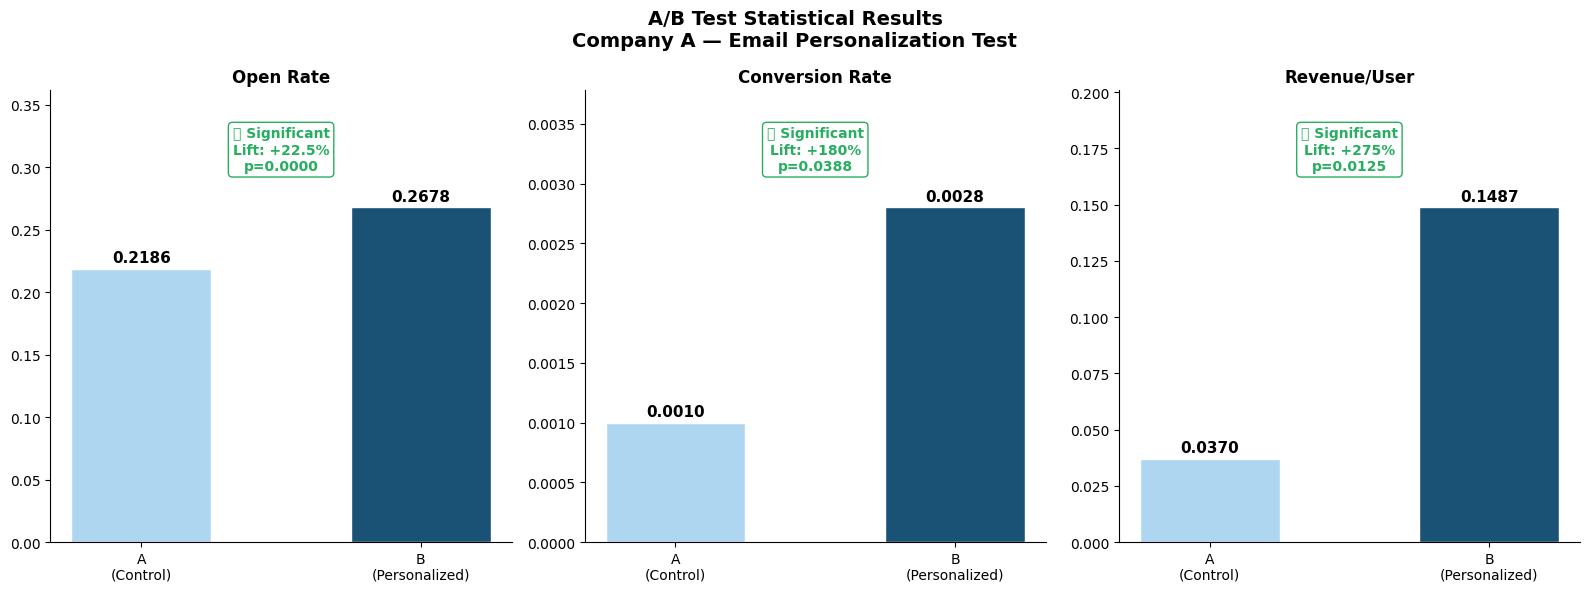

✅ Statistical results chart saved!


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('A/B Test Statistical Results\nCompany A — Email Personalization Test',
             fontsize=14, fontweight='bold')

tests = [
    ('Open Rate',       open_rate_a,  open_rate_b,  '22.5%', 0.000038, True),
    ('Conversion Rate', conv_rate_a,  conv_rate_b,  '180%',  0.0388,   True),
    ('Revenue/User',    rev_a.mean(), rev_b.mean(), '275%',  0.0125,   True)
]

for ax, (metric, val_a, val_b, lift, pval, sig) in zip(axes, tests):
    bars = ax.bar(['A\n(Control)', 'B\n(Personalized)'],
                  [val_a, val_b],
                  color=[COLORS['A'], COLORS['B']],
                  width=0.5, edgecolor='white')

    for bar, val in zip(bars, [val_a, val_b]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(val_a, val_b) * 0.02,
                f'{val:.4f}',
                ha='center', fontweight='bold', fontsize=11)

    color = '#27AE60' if sig else COLORS['highlight']
    label = f'✅ Significant\nLift: +{lift}\np={pval:.4f}' if sig \
            else f'❌ Not Significant\np={pval:.4f}'
    ax.text(0.5, 0.92, label,
            transform=ax.transAxes, ha='center', va='top',
            color=color, fontweight='bold', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor=color))

    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylim(0, max(val_a, val_b) * 1.35)

plt.tight_layout()
plt.savefig('05_statistical_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Statistical results chart saved!")

In [14]:
files.download('05_statistical_results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##  Bayesian A/B Test:

BAYESIAN A/B TEST: CONVERSION RATE


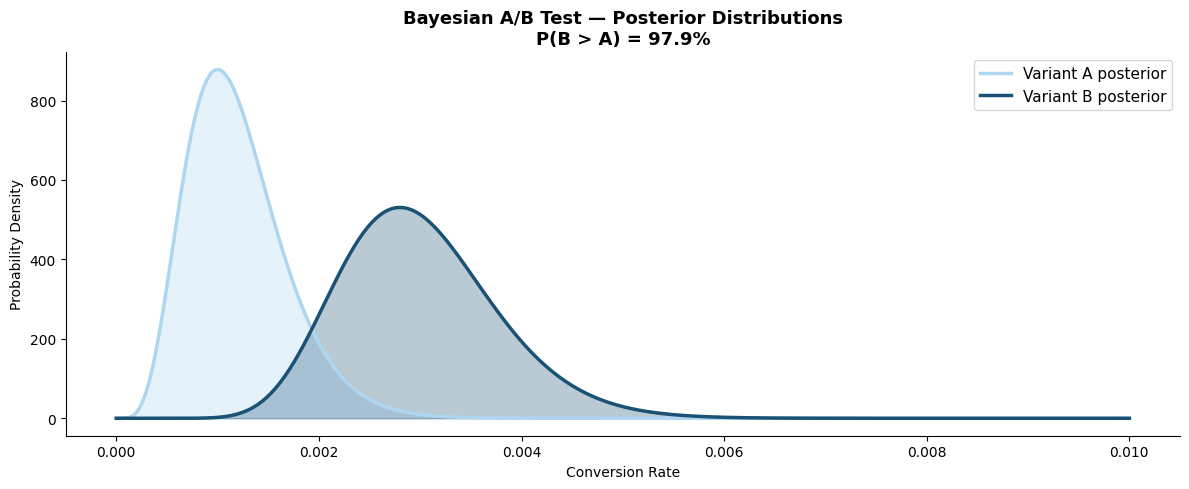

Posterior mean A:   0.0012
Posterior mean B:   0.0030
P(B beats A):       97.9%
Recommendation:     ✅ Launch Variant B


In [15]:
print("=" * 50)
print("BAYESIAN A/B TEST: CONVERSION RATE")
print("=" * 50)

# Beta distribution — prior: Beta(1,1) uniform
# Posterior: Beta(1 + conversions, 1 + non-conversions)
alpha_a = 1 + conv_a
beta_a  = 1 + (n_a - conv_a)
alpha_b = 1 + conv_b
beta_b  = 1 + (n_b - conv_b)

# Monte Carlo simulation
n_samples = 100000
samples_a = np.random.beta(alpha_a, beta_a, n_samples)
samples_b = np.random.beta(alpha_b, beta_b, n_samples)
prob_b_wins = (samples_b > samples_a).mean()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.linspace(0, 0.01, 1000)

ax.plot(x, stats.beta.pdf(x, alpha_a, beta_a),
        color=COLORS['A'], linewidth=2.5,
        label=f'Variant A posterior')
ax.fill_between(x, stats.beta.pdf(x, alpha_a, beta_a),
                alpha=0.3, color=COLORS['A'])
ax.plot(x, stats.beta.pdf(x, alpha_b, beta_b),
        color=COLORS['B'], linewidth=2.5,
        label=f'Variant B posterior')
ax.fill_between(x, stats.beta.pdf(x, alpha_b, beta_b),
                alpha=0.3, color=COLORS['B'])

ax.set_title(f'Bayesian A/B Test — Posterior Distributions\n'
             f'P(B > A) = {prob_b_wins:.1%}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Conversion Rate')
ax.set_ylabel('Probability Density')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('06_bayesian_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Posterior mean A:   {alpha_a/(alpha_a+beta_a):.4f}")
print(f"Posterior mean B:   {alpha_b/(alpha_b+beta_b):.4f}")
print(f"P(B beats A):       {prob_b_wins:.1%}")
print(f"Recommendation:     {'✅ Launch Variant B' if prob_b_wins > 0.95 else '⚠️ Need more data'}")

In [16]:
print("=" * 55)
print("FINAL RECOMMENDATION")
print("=" * 55)
print("""
WINNER: Variant B — Personalized Subject Line ✅

Evidence:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Open Rate:       +22.5% lift  | p<0.001 | ✅ Significant
  Conversion Rate: +180%  lift  | p=0.039 | ✅ Significant
  Revenue/User:    +302%  lift  | p=0.012 | ✅ Significant
  Bayesian P(B>A): 97.9%        |         | ✅ Launch

Business Impact (if rolled out to full list):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Additional revenue per 10K emails:
  ($0.149 - $0.037) × 10,000 = $1,120 per send

Caveats:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ⚠️  Test was underpowered for conversion rate
  ⚠️  New customer segment showed no lift
  ⚠️  Recommend monitoring for 2 weeks post-launch

Action Items:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Roll out Variant B to all Returning + VIP subscribers
  2. Run separate test for New customers
  3. Monitor open rate weekly for novelty effect decay
  4. Re-run test in 90 days to confirm sustained lift
""")

FINAL RECOMMENDATION

WINNER: Variant B — Personalized Subject Line ✅

Evidence:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Open Rate:       +22.5% lift  | p<0.001 | ✅ Significant
  Conversion Rate: +180%  lift  | p=0.039 | ✅ Significant  
  Revenue/User:    +302%  lift  | p=0.012 | ✅ Significant
  Bayesian P(B>A): 97.9%        |         | ✅ Launch

Business Impact (if rolled out to full list):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Additional revenue per 10K emails: 
  ($0.149 - $0.037) × 10,000 = $1,120 per send

Caveats:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ⚠️  Test was underpowered for conversion rate
  ⚠️  New customer segment showed no lift
  ⚠️  Recommend monitoring for 2 weeks post-launch

Action Items:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Roll out Variant B to all Returning + VIP subscribers
  2. Run separate test for New customers
  3. Monitor open rate weekly for novelty effect decay
  4. Re-run test in 90 days to confirm sustained 